In [1]:
from sklearn.model_selection import train_test_split
import pandas as pd 
import numpy as np 

In [2]:
df=pd.read_csv('D:/python ml projects/credit card fraud detection/data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
X=df.drop('Class',axis=1)
y=df['Class']

In [4]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2,stratify=y)

In [5]:
X_train.shape,X_test.shape

((227845, 30), (56962, 30))

In [6]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train[['Amount','Time']]=scaler.fit_transform(X_train[['Amount','Time']])
X_test[['Amount','Time']]=scaler.transform(X_test[['Amount','Time']])

In [7]:
#Dummy Model
from sklearn.metrics import accuracy_score,precision_score,f1_score,recall_score
from sklearn.dummy import DummyClassifier
baseline=DummyClassifier(strategy='most_frequent')
baseline.fit(X_train,y_train)
y_pred_baseline=baseline.predict(X_test)

#Metrics
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_baseline)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_baseline, zero_division=0)*100:.2f}%")
print(f"Recall:    {recall_score(y_test, y_pred_baseline, zero_division=0)*100:.2f}%")
print(f"F1 Score:  {f1_score(y_test, y_pred_baseline, zero_division=0)*100:.2f}%")


Accuracy:  99.83%
Precision: 0.00%
Recall:    0.00%
F1 Score:  0.00%


In [8]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score,classification_report
dt=DecisionTreeClassifier(random_state=42,min_samples_split=5,min_samples_leaf=2,class_weight='balanced',criterion='gini',max_depth=None)
dt.fit(X_train,y_train)
y_pred_dt=dt.predict(X_test)
y_prob_dt=dt.predict_proba(X_test)[:1]

#Metrics
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_dt)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_dt, zero_division=0)*100:.2f}%")
print(f"Recall:    {recall_score(y_test, y_pred_dt, zero_division=0)*100:.2f}%")
print(f"F1 Score:  {f1_score(y_test, y_pred_dt, zero_division=0)*100:.2f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_dt)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, 
                           target_names=['Legitimate', 'Fraud']))


Accuracy:  99.89%
Precision: 65.14%
Recall:    72.45%
F1 Score:  68.60%


ValueError: Found input variables with inconsistent numbers of samples: [56962, 1]

In [ ]:
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"\npredict_proba output shape: {dt.predict_proba(X_test).shape}")
print(f"\nFirst 3 rows of predict_proba:")
print(dt.predict_proba(X_test)[:3])

X_test shape: (56962, 30)
y_test shape: (56962,)

predict_proba output shape: (56962, 2)

First 3 rows of predict_proba:
[[1. 0.]
 [1. 0.]
 [1. 0.]]


In [ ]:

print("Predictions distribution:")
print(f"Predicted legitimate (0): {(y_pred_dt == 0).sum()}")
print(f"Predicted fraud (1):      {(y_pred_dt == 1).sum()}")

print("\nActual distribution:")
print(f"Actual legitimate (0): {(y_test == 0).sum()}")
print(f"Actual fraud (1):      {(y_test == 1).sum()}")

print("\nUnique probability values (first 10):")
print(np.unique(dt.predict_proba(X_test)[:, 1])[:10])

Predictions distribution:
Predicted legitimate (0): 56853
Predicted fraud (1):      109

Actual distribution:
Actual legitimate (0): 56864
Actual fraud (1):      98

Unique probability values (first 10):
[0.         0.99827075 0.99942292 1.        ]


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_dt)
tn, fp, fn, tp = cm.ravel()

print(f"Fraud correctly caught (TP): {tp}")
print(f"Fraud missed (FN):           {fn}")
print(f"Recall: {tp/(tp+fn)*100:.1f}%")

Fraud correctly caught (TP): 71
Fraud missed (FN):           27
Recall: 72.4%


In [ ]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(
    n_estimators=100,        # 100 trees
    max_depth=None,          # Let trees grow fully
    min_samples_split=5,     # Same as our fixed DT
    min_samples_leaf=2,      # Same as our fixed DT
    max_features='sqrt',     # Each tree sees sqrt(30) ≈ 5 features
    class_weight='balanced', # Handle imbalance
    random_state=42,
    n_jobs=-1                # Use all CPU cores
)

rf_model.fit(X_train, y_train)


# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Verify probabilities are varied
print(f"\nProbability check:")
print(f"Min:  {y_prob_rf.min():.4f}")
print(f"Max:  {y_prob_rf.max():.4f}")
print(f"Mean: {y_prob_rf.mean():.4f}")
print(f"Unique values count: {len(np.unique(y_prob_rf))}")


Training Random Forest... (might take 30-60 seconds)
 Training complete! Time taken: 19.8 seconds

Probability check:
Min:  0.0000
Max:  1.0000
Mean: 0.0020
Unique values count: 375


RANDOM FOREST RESULTS

Accuracy:  99.95%
Precision: 93.90%
Recall:    78.57%
F1 Score:  85.56%
ROC-AUC:   95.75%

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.94      0.79      0.86        98

    accuracy                           1.00     56962
   macro avg       0.97      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962



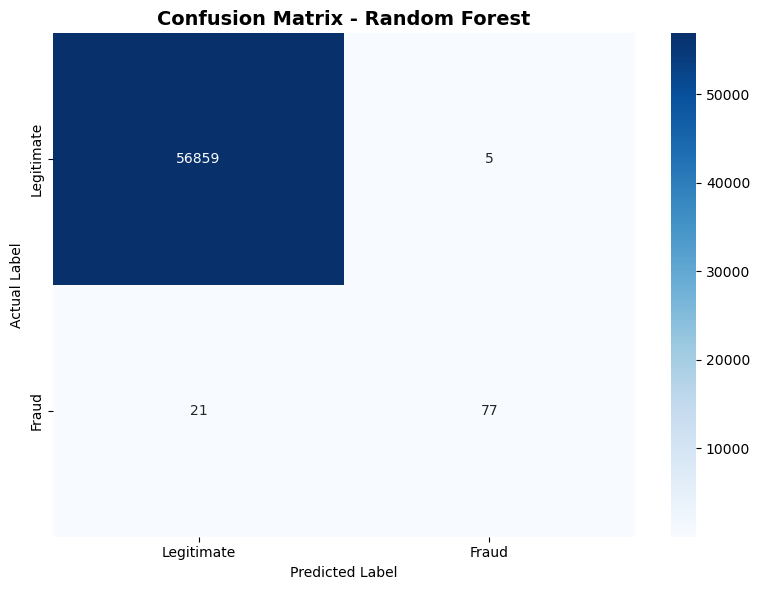


📊 Confusion Matrix Breakdown:
   True Negatives  (TN): 56,859 → Legitimate correctly identified
   False Positives (FP): 5 → Legitimate wrongly flagged as fraud
   False Negatives (FN): 21 → FRAUD MISSED ⚠️
   True Positives  (TP): 77 → Fraud correctly caught ✅

💰 Business Impact:
   Fraud caught:  77/98 (78.6%)
   Fraud missed:  21/98 (21.4%)


In [ ]:
# Confusion matrix function 
import seaborn as sns 
import matplotlib.pyplot as plt
def plot_confusion_matrix(y_test, y_pred, model_name):
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Legitimate', 'Fraud'],
        yticklabels=['Legitimate', 'Fraud']
    )
    plt.title(f'Confusion Matrix - {model_name}', 
              fontsize=14, fontweight='bold')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    
    tn, fp, fn, tp = cm.ravel()
    print(f"\n📊 Confusion Matrix Breakdown:")
    print(f"   True Negatives  (TN): {tn:,} → Legitimate correctly identified")
    print(f"   False Positives (FP): {fp:,} → Legitimate wrongly flagged as fraud")
    print(f"   False Negatives (FN): {fn:,} → FRAUD MISSED ⚠️")
    print(f"   True Positives  (TP): {tp:,} → Fraud correctly caught ✅")
    print(f"\n💰 Business Impact:")
    print(f"   Fraud caught:  {tp}/{tp+fn} ({tp/(tp+fn)*100:.1f}%)")
    print(f"   Fraud missed:  {fn}/{tp+fn} ({fn/(tp+fn)*100:.1f}%)")

print("RANDOM FOREST RESULTS")
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_rf)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_rf)*100:.2f}%")
print(f"Recall:    {recall_score(y_test, y_pred_rf)*100:.2f}%")
print(f"F1 Score:  {f1_score(y_test, y_pred_rf)*100:.2f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_rf)*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf,
                           target_names=['Legitimate', 'Fraud']))

plot_confusion_matrix(y_test, y_pred_rf, "Random Forest")

In [ ]:

print(f"{'MODEL':<20}{'ACCURACY':>10}{'PRECISION':>10}{'RECALL':>10}{'F1':>10}")

results = {
    'Baseline':      (y_pred_baseline, None),
    'Decision Tree': (y_pred_dt, y_prob_dt),
    'Random Forest': (y_pred_rf, y_prob_rf)
}

for name, (y_pred, y_prob) in results.items():
    acc  = accuracy_score(y_test, y_pred) * 100
    prec = precision_score(y_test, y_pred, zero_division=0) * 100
    rec  = recall_score(y_test, y_pred, zero_division=0) * 100
    f1   = f1_score(y_test, y_pred, zero_division=0) * 100
    print(f"{name:<20}{acc:>9.2f}%{prec:>9.2f}%{rec:>9.2f}%{f1:>9.2f}%")

MODEL                 ACCURACY PRECISION    RECALL        F1
Baseline                99.83%     0.00%     0.00%     0.00%
Decision Tree           99.89%    65.14%    72.45%    68.60%
Random Forest           99.95%    93.90%    78.57%    85.56%


In [ ]:
#ROC Curve
from sklearn.metrics import roc_curve
plt.figure(figsize=(10, 7))

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)
plt.plot(fpr_dt, tpr_dt,
         color='blue',
         linewidth=2,
         label=f'Decision Tree (AUC = {auc_dt:.3f})')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf,
         color='green',
         linewidth=2,
         label=f'Random Forest (AUC = {auc_rf:.3f})')

# Baseline diagonal
plt.plot([0, 1], [0, 1],
         color='red',
         linestyle='--',
         linewidth=1.5,
         label='Baseline (AUC = 0.500)')

# Ideal point marker
plt.scatter([0], [1],
            color='gold',
            s=200,
            zorder=5,
            label='Perfect Classifier')

plt.title('ROC Curve - Model Comparison', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate\n(Legitimate flagged as Fraud)')
plt.ylabel('True Positive Rate\n(Fraud correctly caught)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📊 AUC Scores:")
print(f"   Decision Tree: {auc_dt:.4f}")
print(f"   Random Forest: {auc_rf:.4f}")
print(f"   Improvement:   +{(auc_rf-auc_dt)*100:.2f}%")

ValueError: Found input variables with inconsistent numbers of samples: [56962, 1]

<Figure size 1000x700 with 0 Axes>

#  FINAL WORKING VERSION 

All cells above were for learning/debugging. 
This section contains clean, production-ready code.

**To reproduce results:**
1. Restart kernel
2. Run all cells in this section in order

In [12]:


# ---- IMPORTS ----

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score,
    recall_score, f1_score,
    roc_auc_score, roc_curve
)

print("✅ Step 1/6: Imports done!")

# ---- LOAD DATA ----
df = pd.read_csv('D:/python ml projects/credit card fraud detection/data/creditcard.csv')  # change path if needed
print(f"✅ Step 2/6: Data loaded! Shape: {df.shape}")

# ---- PREPROCESSING ----
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train = X_train.copy()
X_test  = X_test.copy()

scaler = StandardScaler()
X_train[['Amount', 'Time']] = scaler.fit_transform(X_train[['Amount', 'Time']])
X_test[['Amount', 'Time']]  = scaler.transform(X_test[['Amount', 'Time']])

print(f"✅ Step 3/6: Preprocessing done!")
print(f"   X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"   y_train: {y_train.shape}, y_test: {y_test.shape}")

# ---- BASELINE ----
baseline = DummyClassifier(strategy='most_frequent', random_state=42)
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)
print(f"✅ Step 4/6: Baseline trained!")

# ---- DECISION TREE ----
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    criterion='gini'
)
dt_model.fit(X_train, y_train)
y_pred_dt  = dt_model.predict(X_test)
y_prob_dt  = dt_model.predict_proba(X_test)[:, 1]

print(f"✅ Step 5/6: Decision Tree trained!")
print(f"   y_pred_dt shape:  {y_pred_dt.shape}")
print(f"   y_prob_dt shape:  {y_prob_dt.shape}")
print(f"   Unique probs:     {len(np.unique(y_prob_dt))}")

# ---- RANDOM FOREST ----
print("\nTraining Random Forest (30-60 seconds)...")
start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf  = rf_model.predict(X_test)
y_prob_rf  = rf_model.predict_proba(X_test)[:, 1]

print(f"✅ Step 6/6: Random Forest trained! ({time.time()-start:.1f}s)")
print(f"   y_pred_rf shape:  {y_pred_rf.shape}")
print(f"   y_prob_rf shape:  {y_prob_rf.shape}")
print(f"   Unique probs:     {len(np.unique(y_prob_rf))}")

# ---- FINAL SHAPE VERIFICATION ----
print("\n" + "="*50)
print("SHAPE VERIFICATION")
print("="*50)
print(f"y_test shape:        {y_test.shape}")
print(f"y_pred_baseline:     {y_pred_baseline.shape}")
print(f"y_pred_dt:           {y_pred_dt.shape}")
print(f"y_prob_dt:           {y_prob_dt.shape}")
print(f"y_pred_rf:           {y_pred_rf.shape}")
print(f"y_prob_rf:           {y_prob_rf.shape}")

# All shapes should be (56962,)
all_correct = all([
    y_test.shape == y_pred_dt.shape,
    y_test.shape == y_prob_dt.shape,
    y_test.shape == y_pred_rf.shape,
    y_test.shape == y_prob_rf.shape
])
print(f"\n{'✅ ALL SHAPES MATCH!' if all_correct else '❌ SHAPE MISMATCH!'}")

✅ Step 1/6: Imports done!
✅ Step 2/6: Data loaded! Shape: (284807, 31)
✅ Step 3/6: Preprocessing done!
   X_train: (227845, 30), X_test: (56962, 30)
   y_train: (227845,), y_test: (56962,)
✅ Step 4/6: Baseline trained!
✅ Step 5/6: Decision Tree trained!
   y_pred_dt shape:  (56962,)
   y_prob_dt shape:  (56962,)
   Unique probs:     4

Training Random Forest (30-60 seconds)...
✅ Step 6/6: Random Forest trained! (23.7s)
   y_pred_rf shape:  (56962,)
   y_prob_rf shape:  (56962,)
   Unique probs:     375

SHAPE VERIFICATION
y_test shape:        (56962,)
y_pred_baseline:     (56962,)
y_pred_dt:           (56962,)
y_prob_dt:           (56962,)
y_pred_rf:           (56962,)
y_prob_rf:           (56962,)

✅ ALL SHAPES MATCH!


In [11]:

#  Confusion Matrix

def plot_confusion_matrix(y_test, y_pred, model_name):
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Legitimate', 'Fraud'],
        yticklabels=['Legitimate', 'Fraud']
    )
    plt.title(f'Confusion Matrix - {model_name}',
              fontsize=14, fontweight='bold')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    tn, fp, fn, tp = cm.ravel()
    print(f"\n📊 Confusion Matrix Breakdown:")
    print(f"   True Negatives  (TN): {tn:,} → Legitimate correctly identified")
    print(f"   False Positives (FP): {fp:,} → Legitimate wrongly flagged as fraud")
    print(f"   False Negatives (FN): {fn:,} → FRAUD MISSED ⚠️")
    print(f"   True Positives  (TP): {tp:,} → Fraud correctly caught ✅")
    print(f"\n💰 Business Impact:")
    print(f"   Fraud caught: {tp}/{tp+fn} ({tp/(tp+fn)*100:.1f}%)")
    print(f"   Fraud missed: {fn}/{tp+fn} ({fn/(tp+fn)*100:.1f}%)")

BASELINE RESULTS
Accuracy:  99.83%
Precision: 0.00%
Recall:    0.00%
F1 Score:  0.00%

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.00      0.00      0.00        98

    accuracy                           1.00     56962
   macro avg       0.50      0.50      0.50     56962
weighted avg       1.00      1.00      1.00     56962

DECISION TREE RESULTS
Accuracy:  99.89%
Precision: 65.14%
Recall:    72.45%
F1 Score:  68.60%
ROC-AUC:   86.19%

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.65      0.72      0.69        98

    accuracy                           1.00     56962
   macro avg       0.83      0.86      0.84     56962
weighted avg       1.00      1.00      1.00     56962

RANDOM FOREST RESULTS
Accuracy:  99.95%
Precision: 93.90%
Recall:    78.57%
F1 Score:  85.56%
ROC-AU

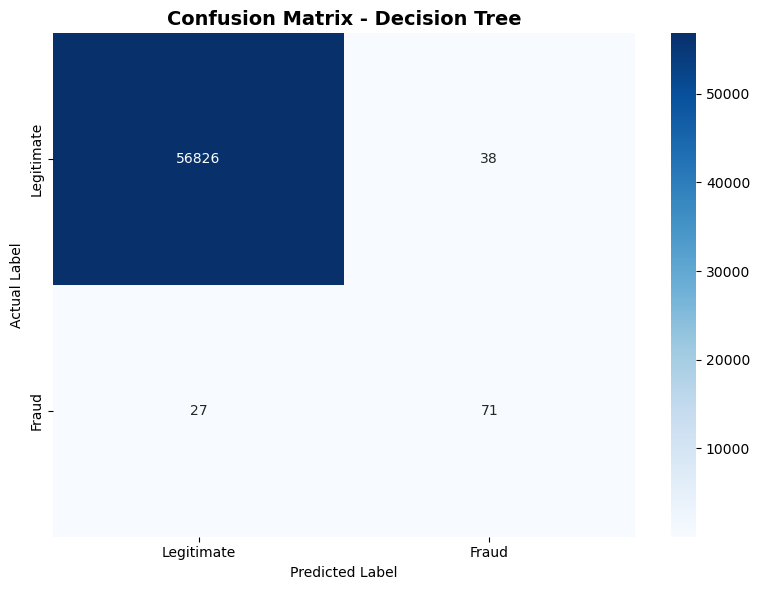


📊 Confusion Matrix Breakdown:
   True Negatives  (TN): 56,826 → Legitimate correctly identified
   False Positives (FP): 38 → Legitimate wrongly flagged as fraud
   False Negatives (FN): 27 → FRAUD MISSED ⚠️
   True Positives  (TP): 71 → Fraud correctly caught ✅

💰 Business Impact:
   Fraud caught: 71/98 (72.4%)
   Fraud missed: 27/98 (27.6%)


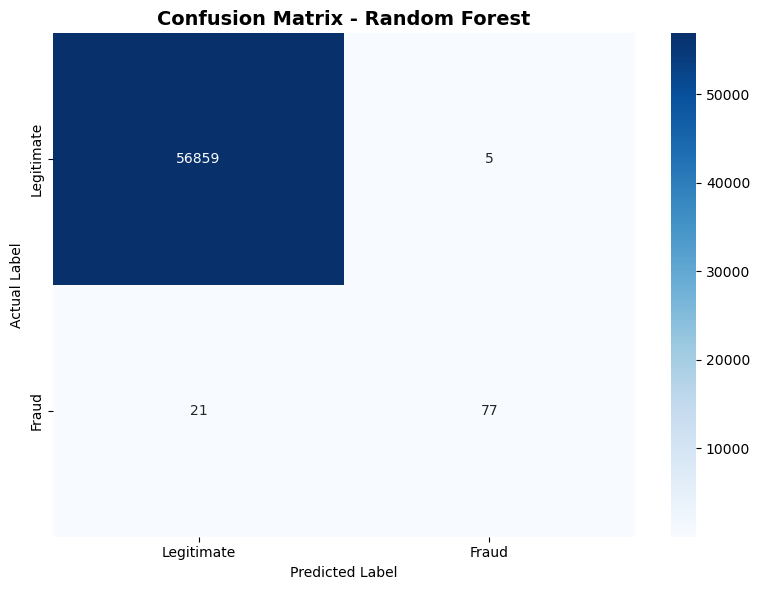


📊 Confusion Matrix Breakdown:
   True Negatives  (TN): 56,859 → Legitimate correctly identified
   False Positives (FP): 5 → Legitimate wrongly flagged as fraud
   False Negatives (FN): 21 → FRAUD MISSED ⚠️
   True Positives  (TP): 77 → Fraud correctly caught ✅

💰 Business Impact:
   Fraud caught: 77/98 (78.6%)
   Fraud missed: 21/98 (21.4%)


In [10]:

# EVALUATE ALL MODELS


def print_metrics(name, y_test, y_pred, y_prob=None):
    print(f"{name} RESULTS")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred)*100:.2f}%")
    print(f"Precision: {precision_score(y_test, y_pred, zero_division=0)*100:.2f}%")
    print(f"Recall:    {recall_score(y_test, y_pred, zero_division=0)*100:.2f}%")
    print(f"F1 Score:  {f1_score(y_test, y_pred, zero_division=0)*100:.2f}%")
    if y_prob is not None:
        print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob)*100:.2f}%")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred,
                               target_names=['Legitimate', 'Fraud'],
                               zero_division=0))

# Evaluate all models
print_metrics("BASELINE",      y_test, y_pred_baseline)
print_metrics("DECISION TREE", y_test, y_pred_dt, y_prob_dt)
print_metrics("RANDOM FOREST", y_test, y_pred_rf, y_prob_rf)

# Confusion matrices
plot_confusion_matrix(y_test, y_pred_dt, "Decision Tree")
plot_confusion_matrix(y_test, y_pred_rf, "Random Forest")

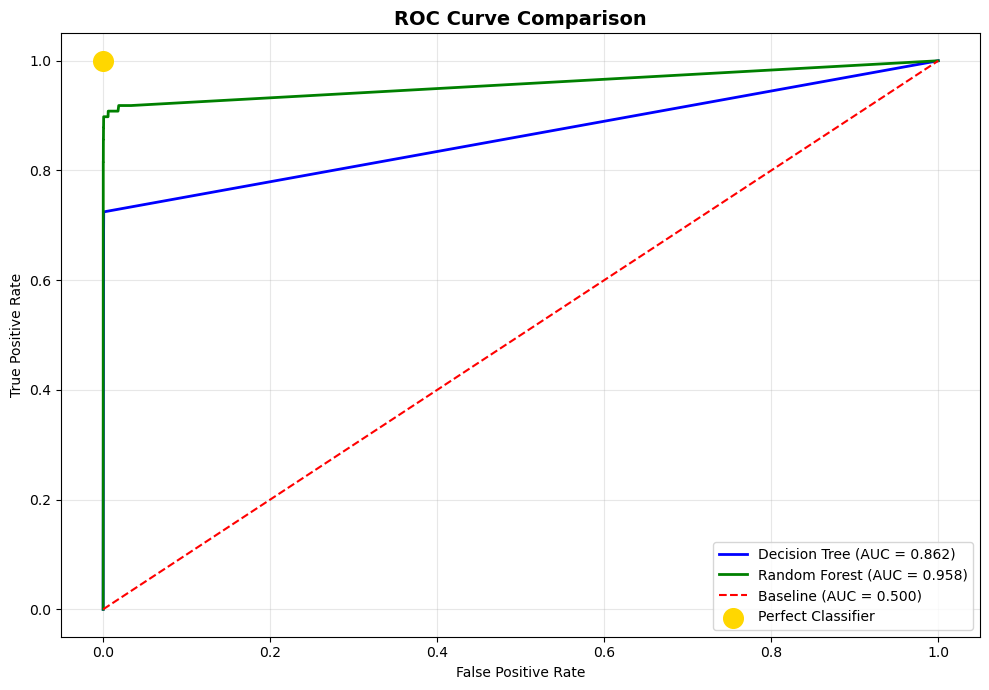


 AUC Scores:
   Decision Tree: 0.8619
   Random Forest: 0.9575
   Improvement:   +9.56%


In [9]:

# ROC CURVE COMPARISON


plt.figure(figsize=(10, 7))

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)
plt.plot(fpr_dt, tpr_dt, color='blue', linewidth=2,
         label=f'Decision Tree (AUC = {auc_dt:.3f})')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, color='green', linewidth=2,
         label=f'Random Forest (AUC = {auc_rf:.3f})')

# Baseline
plt.plot([0, 1], [0, 1], color='red', linestyle='--',
         linewidth=1.5, label='Baseline (AUC = 0.500)')

# Perfect point
plt.scatter([0], [1], color='gold', s=200, zorder=5,
            label='Perfect Classifier')

plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n AUC Scores:")
print(f"   Decision Tree: {auc_dt:.4f}")
print(f"   Random Forest: {auc_rf:.4f}")
print(f"   Improvement:   +{(auc_rf - auc_dt)*100:.2f}%")

TOP 10 MOST IMPORTANT FEATURES:
  feature  importance
0     V14    0.182739
1     V10    0.116403
2     V12    0.096630
3      V4    0.093883
4     V17    0.091426
5      V3    0.066751
6     V11    0.053911
7     V16    0.040791
8      V2    0.035833
9      V9    0.026035


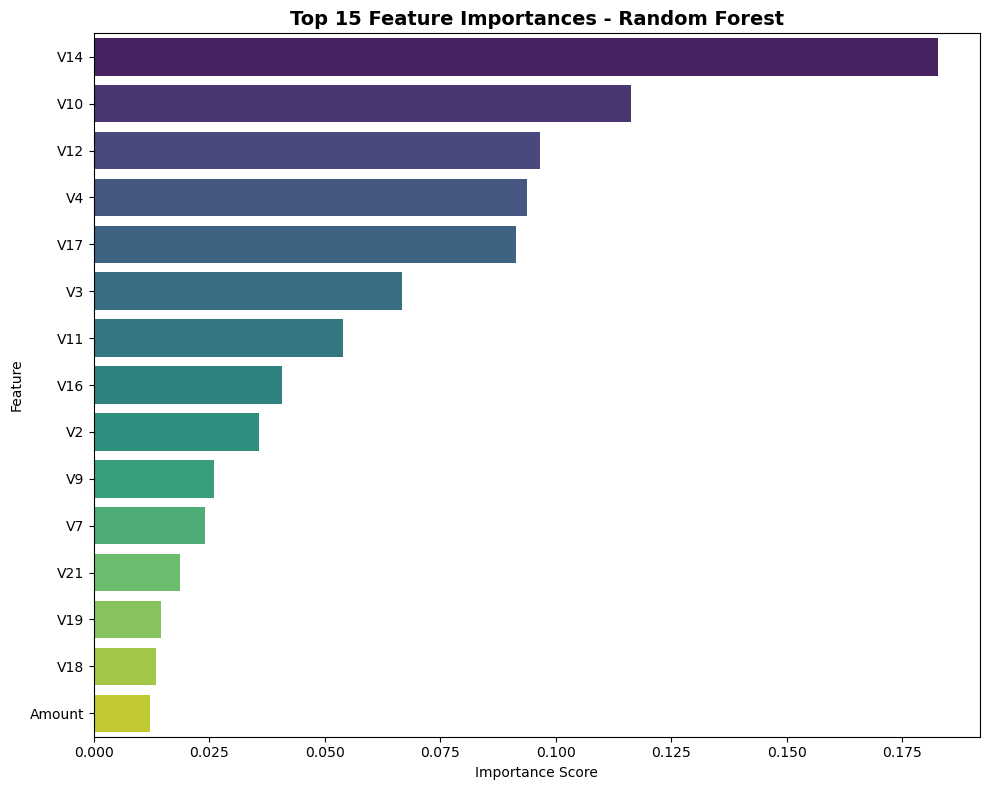

In [ ]:

# FEATURE IMPORTANCE


feature_importance = pd.DataFrame({
    'feature':    X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("TOP 10 MOST IMPORTANT FEATURES:")
print(feature_importance.head(10))

plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_importance.head(15),
    x='importance',
    y='feature',
    palette='viridis'
)
plt.title('Top 15 Feature Importances - Random Forest',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [8]:

# FINAL MODEL COMPARISON TABLE


print("="*65)
print(f"{'MODEL':<20}{'ACCURACY':>10}{'PRECISION':>10}"
      f"{'RECALL':>10}{'F1':>10}")
print("="*65)

all_models = {
    'Baseline':      (y_pred_baseline, None),
    'Decision Tree': (y_pred_dt,       y_prob_dt),
    'Random Forest': (y_pred_rf,       y_prob_rf)
}

for name, (y_pred, y_prob) in all_models.items():
    acc  = accuracy_score(y_test, y_pred) * 100
    prec = precision_score(y_test, y_pred, zero_division=0) * 100
    rec  = recall_score(y_test, y_pred, zero_division=0) * 100
    f1   = f1_score(y_test, y_pred, zero_division=0) * 100
    print(f"{name:<20}{acc:>9.2f}%{prec:>9.2f}%"
          f"{rec:>9.2f}%{f1:>9.2f}%")




MODEL                 ACCURACY PRECISION    RECALL        F1
Baseline                99.83%     0.00%     0.00%     0.00%
Decision Tree           99.89%    65.14%    72.45%    68.60%
Random Forest           99.95%    93.90%    78.57%    85.56%


In [13]:
import joblib

# Save model and scaler
joblib.dump(rf_model, 'fraud_detection_rf_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model and scaler saved")

Model and scaler saved


In [ ]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler

# ============================================================
# PAGE CONFIGURATION
# ============================================================
st.set_page_config(
    page_title="Credit Card Fraud Detector",
    page_icon="🔒",
    layout="wide"
)

# ============================================================
# LOAD MODEL AND SCALER
# ============================================================
@st.cache_resource
def load_model():
    """Load the trained model and scaler"""
    model = joblib.load('fraud_detection_rf_model.pkl')
    scaler = joblib.load('scaler.pkl')
    return model, scaler

model, scaler = load_model()

# ============================================================
# HEADER
# ============================================================
st.title("🔒 Credit Card Fraud Detection System")
st.markdown("""
This machine learning system detects fraudulent credit card transactions using a 
**Random Forest classifier** trained on real transaction data.

**Model Performance:**
- 🎯 **78.6% Recall** - Catches 78.6% of all fraud
- ✅ **93.9% Precision** - 94% of flagged transactions are actual fraud  
- 📊 **85.6% F1 Score** - Excellent overall performance

Upload transaction data below to get instant fraud predictions!
""")

st.divider()

# ============================================================
# SIDEBAR - INFO
# ============================================================
st.sidebar.header("ℹ️ About")
st.sidebar.info("""
**How it works:**
1. Upload a CSV file with transaction data
2. Model analyzes 30 features using Random Forest
3. Get fraud probability for each transaction
4. Download results

**Required columns:**
- V1, V2, ..., V28 (PCA features)
- Amount
- Time

**Model:** Random Forest with 100 trees
**Training data:** 284,807 transactions
""")

st.sidebar.divider()
st.sidebar.header("📊 Model Details")
st.sidebar.metric("F1 Score", "85.6%")
st.sidebar.metric("Precision", "93.9%")
st.sidebar.metric("Recall", "78.6%")

# ============================================================
# FILE UPLOAD
# ============================================================
st.header("📁 Upload Transaction Data")

uploaded_file = st.file_uploader(
    "Choose a CSV file",
    type=['csv'],
    help="Upload a CSV file with transaction features (V1-V28, Amount, Time)"
)

if uploaded_file is not None:
    # Load data
    df = pd.read_csv(uploaded_file)
    
    st.success(f"✅ File uploaded successfully! {len(df)} transactions loaded.")
    
    # Show sample
    with st.expander("👁️ View uploaded data (first 5 rows)"):
        st.dataframe(df.head())
    
    # ============================================================
    # DATA VALIDATION
    # ============================================================
    required_columns = ['Time', 'Amount'] + [f'V{i}' for i in range(1, 29)]
    missing_columns = [col for col in required_columns if col not in df.columns]
    
    if missing_columns:
        st.error(f"❌ Missing required columns: {missing_columns}")
        st.stop()
    
    # ============================================================
    # PREPROCESSING
    # ============================================================
    st.header("⚙️ Processing Transactions...")
    
    with st.spinner("Scaling features..."):
        # Make a copy
        df_processed = df.copy()
        
        # Scale Amount and Time
        df_processed[['Amount', 'Time']] = scaler.transform(df_processed[['Amount', 'Time']])
        
        # Prepare features (same order as training)
        feature_columns = ['Time'] + [f'V{i}' for i in range(1, 29)] + ['Amount']
        X = df_processed[feature_columns]
    
    # ============================================================
    # PREDICTIONS
    # ============================================================
    with st.spinner("Making predictions..."):
        predictions = model.predict(X)
        probabilities = model.predict_proba(X)[:, 1]  # Fraud probability
    
    # Add results to dataframe
    df['Prediction'] = ['🚨 FRAUD' if p == 1 else '✅ Legitimate' for p in predictions]
    df['Fraud_Probability'] = probabilities
    df['Risk_Level'] = pd.cut(
        probabilities,
        bins=[0, 0.3, 0.7, 1.0],
        labels=['🟢 Low', '🟡 Medium', '🔴 High']
    )
    
    st.success("✅ Analysis complete!")
    
    # ============================================================
    # RESULTS SUMMARY
    # ============================================================
    st.header("📊 Results Summary")
    
    col1, col2, col3, col4 = st.columns(4)
    
    total_transactions = len(df)
    fraud_detected = (predictions == 1).sum()
    fraud_percentage = (fraud_detected / total_transactions) * 100
    avg_fraud_prob = probabilities.mean() * 100
    
    with col1:
        st.metric(
            "Total Transactions",
            f"{total_transactions:,}"
        )
    
    with col2:
        st.metric(
            "Fraud Detected",
            f"{fraud_detected:,}",
            f"{fraud_percentage:.2f}%"
        )
    
    with col3:
        st.metric(
            "Legitimate",
            f"{total_transactions - fraud_detected:,}"
        )
    
    with col4:
        st.metric(
            "Avg Fraud Probability",
            f"{avg_fraud_prob:.2f}%"
        )
    
    # ============================================================
    # DETAILED RESULTS
    # ============================================================
    st.header("🔍 Detailed Results")
    
    # Tabs for different views
    tab1, tab2, tab3 = st.tabs(["📋 All Transactions", "🚨 Flagged Fraud", "📈 Risk Distribution"])
    
    with tab1:
        st.dataframe(
            df[['Time', 'Amount', 'Prediction', 'Fraud_Probability', 'Risk_Level']],
            use_container_width=True
        )
    
    with tab2:
        fraud_df = df[predictions == 1]
        if len(fraud_df) > 0:
            st.write(f"**{len(fraud_df)} fraudulent transactions detected:**")
            st.dataframe(
                fraud_df[['Time', 'Amount', 'Fraud_Probability', 'Risk_Level']].sort_values(
                    'Fraud_Probability',
                    ascending=False
                ),
                use_container_width=True
            )
        else:
            st.info("✅ No fraudulent transactions detected!")
    
    with tab3:
        # Risk distribution chart
        risk_counts = df['Risk_Level'].value_counts()
        st.bar_chart(risk_counts)
    
    # ============================================================
    # DOWNLOAD RESULTS
    # ============================================================
    st.header("💾 Download Results")
    
    # Prepare download
    csv = df.to_csv(index=False).encode('utf-8')
    
    st.download_button(
        label="📥 Download Full Results (CSV)",
        data=csv,
        file_name="fraud_detection_results.csv",
        mime="text/csv",
        help="Download complete results with predictions"
    )
    
else:
    # ============================================================
    # SAMPLE DATA OPTION
    # ============================================================
    st.info("👆 Upload a CSV file to get started, or try with sample data below")
    
    if st.button("🧪 Test with Sample Data"):
        st.info("Sample data feature coming soon! For now, please upload your own CSV.")

# ============================================================
# FOOTER
# ============================================================
st.divider()
st.markdown("""
<div style='text-align: center; color: gray;'>
    <p>Built with Streamlit • Random Forest Model • 85.6% F1 Score</p>
    <p>Created as part of a Data Science portfolio project</p>
</div>
""", unsafe_allow_html=True)

ModuleNotFoundError: No module named 'streamlit'